In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

-------------------------------
 1. Load Dataset
-------------------------------

In [33]:
df = pd.read_csv("social_media_engagement_dataset.csv")

In [34]:
df.columns = df.columns.str.strip().str.lower()

-------------------------------
  2. Clean Dataset 
-------------------------------

In [35]:
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)

-------------------------------
  3. Engagement Metrics
-------------------------------

In [36]:
df["engagement_calc"] = df["likes"] + df["comments"] + df["shares"]
df["engagement_rate_calc"] = df["engagement_calc"] / df["follower_count"]


-------------------------------
  4. Most Engaging Posts
-------------------------------

C:\Users\user\AppData\Local\Temp\ipykernel_19300\2132115818.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="engagement_rate_calc", y="post_id", data=top_posts_rate, palette="magma")


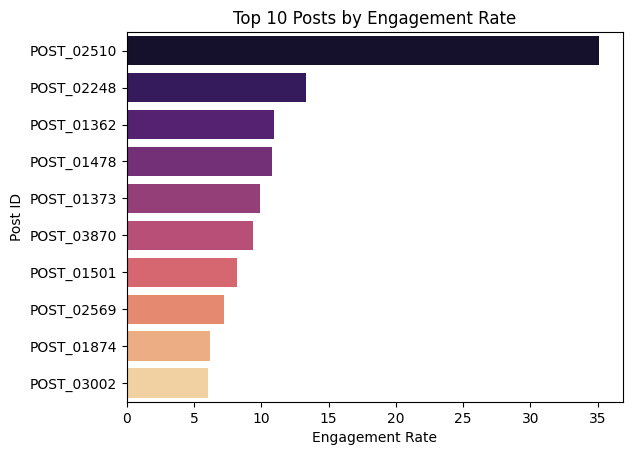

In [37]:
top_posts_rate = df.sort_values(by="engagement_rate_calc", ascending=False).head(10)

sns.barplot(x="engagement_rate_calc", y="post_id", data=top_posts_rate, palette="magma")
plt.title("Top 10 Posts by Engagement Rate")
plt.xlabel("Engagement Rate")
plt.ylabel("Post ID")
plt.show()

-------------------------------
  5. Engagement Rate
-------------------------------

In [38]:
df["engagement"] = df["likes"] + df["comments"] + df["shares"]
df["engagement_rate"] = df["engagement"] / df["follower_count"]

-------------------------------
  6. Exploratory Data Analysis
-------------------------------

C:\Users\user\AppData\Local\Temp\ipykernel_19300\568987413.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="engagement_calc", y="post_id", data=top_posts, palette="viridis")


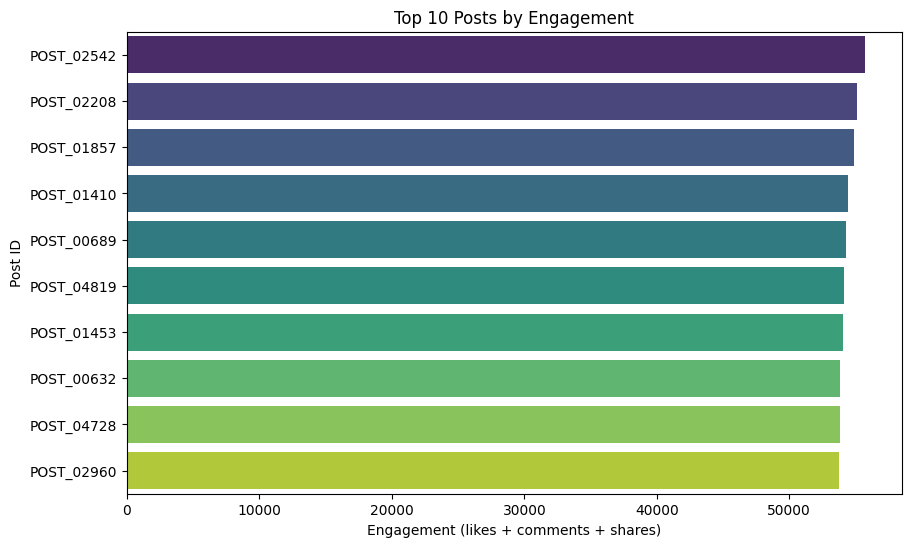

Insight: These posts generated the highest combined likes, shares, and comments.


In [39]:
# Top 10 posts by engagement

top_posts = df.sort_values(by="engagement_calc", ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x="engagement_calc", y="post_id", data=top_posts, palette="viridis")
plt.title("Top 10 Posts by Engagement")
plt.xlabel("Engagement (likes + comments + shares)")
plt.ylabel("Post ID")
plt.show()

print("Insight: These posts generated the highest combined likes, shares, and comments.")

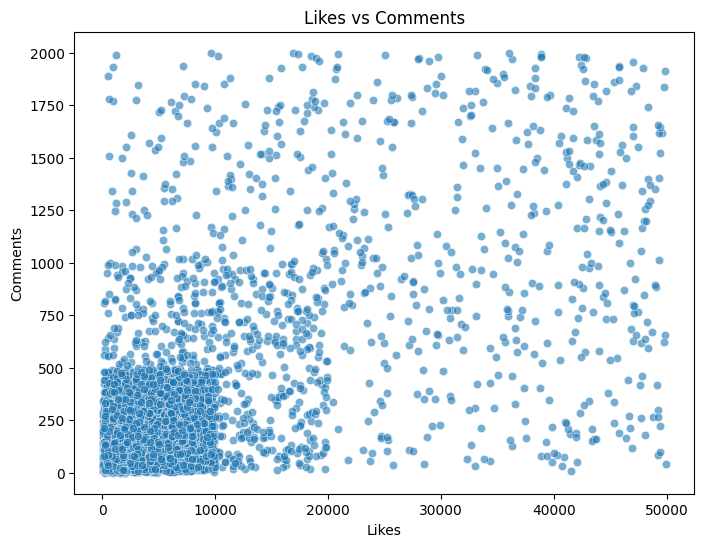

Insight: Positive correlation suggests posts with more likes also attract more comments.


In [40]:
# Likes vs Comments scatter plot

plt.figure(figsize=(8,6))
sns.scatterplot(x="likes", y="comments", data=df, alpha=0.6)
plt.title("Likes vs Comments")
plt.xlabel("Likes")
plt.ylabel("Comments")
plt.show()
print("Insight: Positive correlation suggests posts with more likes also attract more comments.")

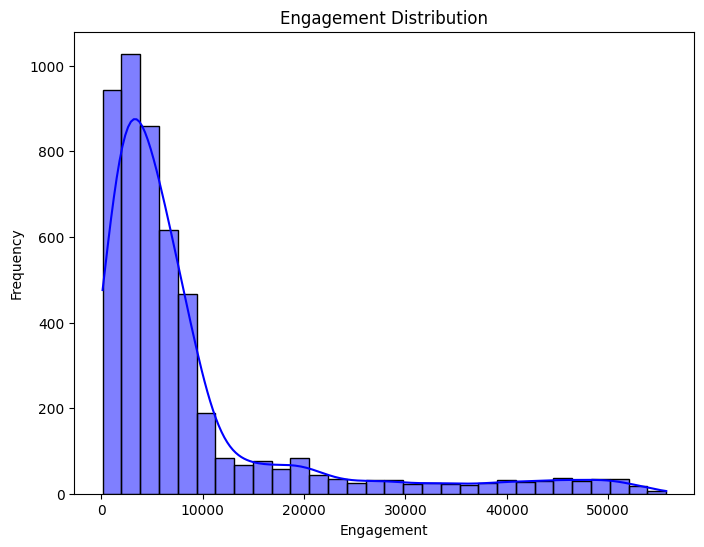

Insight: Majority of posts cluster around lower engagement, with few viral outliers.


In [41]:
# Engagement distribution

plt.figure(figsize=(8,6))
sns.histplot(df["engagement"], bins=30, kde=True, color="blue")
plt.title("Engagement Distribution")
plt.xlabel("Engagement")
plt.ylabel("Frequency")
plt.show()
print("Insight: Majority of posts cluster around lower engagement, with few viral outliers.")